<h1 align="center"> Credit Risk Analysis</h1>

## 📌 Objective
To predict the probability of loan default and identify key risk factors using machine learning techniques.

## 🚀 Key Highlights
- Applied WOE & IV for feature engineering (industry standard)
- Compared Logistic Regression, Random Forest, XGBoost
- Evaluated using ROC-AUC and KS Statistic
- Built Streamlit app for real-time predictions

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
import math
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,f1_score,make_scorer,roc_curve,auc
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.stats import uniform, randint
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
import optuna

In [2]:
pd.set_option('display.float_format',lambda x: '{:.2f}'.format(x))
np.set_printoptions(suppress=True)


### Load Data

In [3]:
df_customers=pd.read_csv("C:/Users/elzab/Documents/Job/Data Science Learn/Project Credit Risk/Project2_DataCollection_Resources/customers.csv")
df_loans=pd.read_csv("C:/Users/elzab/Documents/Job/Data Science Learn/Project Credit Risk/Project2_DataCollection_Resources/loans.csv")
df_bureau=pd.read_csv("C:/Users/elzab/Documents/Job/Data Science Learn/Project Credit Risk/Project2_DataCollection_Resources/bureau_data.csv")

<h1 align="center"> Dataset Overview <h1>

In [4]:
df_customers.shape,df_loans.shape,df_bureau.shape

((50000, 12), (50000, 15), (50000, 8))

In [5]:
df_customers.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001


In [6]:
df_loans.head()

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [7]:
df_bureau.head()

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10


In [8]:
df=pd.merge(df_customers,df_loans,on="cust_id")
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [9]:
df=pd.merge(df,df_bureau)
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [11]:
df["default"]=df["default"].astype(int)
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

default is a target variable and we can see some class imbalance here. We will address it later on.

### Train Test split 

We perform train test split before doing EDA to prevent data leakage. We don't want test set (which is part of the entire dataset) to influence EDA or any decisions on feature engineering.

In [12]:
X=df.drop("default",axis=1)
y=df["default"]

X_train,x_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.25,random_state=42)

stratify=y prevents class imbalance by ensuring the same proportion of each class appears in both splits. keep the same class ratio as the original dataset

In [13]:
df_train=pd.concat([X_train,y_train],axis="columns")
df_test=pd.concat([x_test,y_test],axis="columns")

In [14]:
df_train.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,2020-10-31,2020-11-11,4,2,152,20,118,4,36,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,2022-10-22,2022-10-27,3,1,160,10,62,5,5,0
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,...,2023-12-04,2023-12-29,1,1,54,12,67,4,0,0


<h1 align="center"> 🧹 Data Preprocessing </h1>

Handling missing values and preparing data for modeling.

#### Handle Missing & Duplicate Values

In [15]:
df_train.shape,df_test.shape

((37500, 33), (12500, 33))

In [16]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [17]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [18]:
mode_residence=df_train.residence_type.mode()[0]
mode_residence

'Owned'

In [19]:
df_train["residence_type"]=df_train.residence_type.fillna(mode_residence)

In [20]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [21]:
df_test["residence_type"]=df_test.residence_type.fillna(mode_residence)

In [22]:
df_train.duplicated().sum()

0

In [23]:
df_train.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,...,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
count,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,...,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00
mean,39.54,2633326.16,1.94,16.00,418866.25,4699691.57,3996067.73,80290.68,719292.19,3196854.19,...,1333819.51,986298.87,2.50,1.00,76.11,4.84,26.67,5.01,43.42,0.09
std,9.86,2623780.52,1.54,8.92,169035.02,6257832.98,5371862.29,113128.14,966935.21,4297489.83,...,1213674.44,1043145.01,1.12,0.81,43.77,5.84,32.78,2.03,29.39,0.28
min,18.00,0.00,0.00,1.00,110001.00,0.00,0.00,0.00,0.00,0.00,...,-1.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
25%,33.00,802000.00,0.00,8.00,302001.00,1142000.00,961000.00,19220.00,172980.00,768800.00,...,422197.50,287040.25,1.00,0.00,42.00,0.00,0.00,4.00,18.00,0.00
50%,39.00,1885000.00,2.00,16.00,400001.00,2644000.00,2230000.00,44600.00,401400.00,1784000.00,...,997427.50,665014.50,3.00,1.00,71.00,3.00,13.00,5.00,39.00,0.00
75%,46.00,3326250.00,3.00,24.00,560001.00,5178000.00,4619000.00,92420.00,831420.00,3695200.00,...,1784879.00,1234062.75,4.00,2.00,107.00,8.00,46.00,6.00,67.00,0.00
max,70.00,11999000.00,5.00,31.00,700001.00,52175000.00,47819000.00,5293543.52,8607420.00,38255200.00,...,5000000.00,7846643.00,4.00,2.00,223.00,24.00,171.00,9.00,99.00,1.00


In [24]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [25]:
columns_continuous = ['age', 'income', 'number_of_dependants', 'years_at_current_address', 
                      'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement', 
                      'loan_tenure_months','principal_outstanding', 'bank_balance_at_application',
                      'number_of_open_accounts','number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
                       'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

columns_categorical = ['gender', 'marital_status', 'employment_status', 'residence_type', 'city', 
                       'state', 'zipcode', 'loan_purpose', 'loan_type', 'default']

#### Box plot to visualize outliers

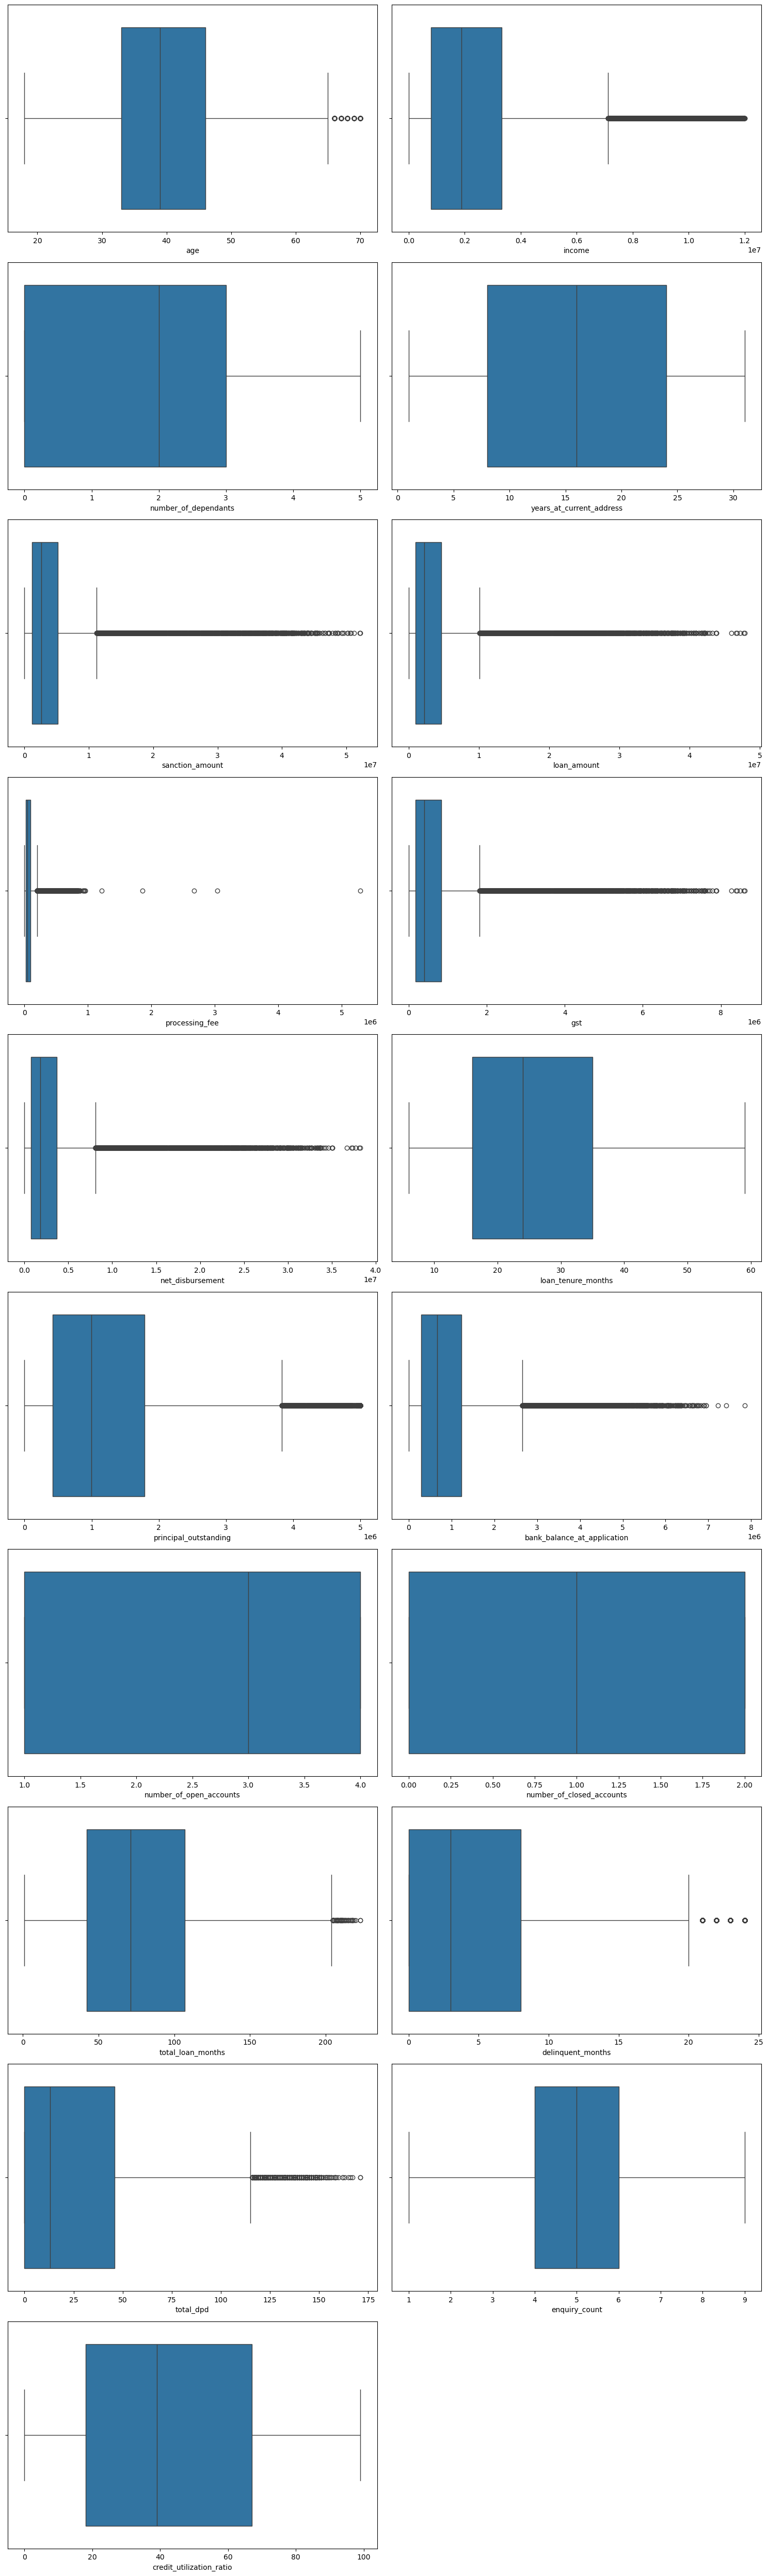

In [26]:
cols=columns_continuous
n_cols=2
n_rows=math.ceil(len(cols)/n_cols)
plt.figure(figsize=(15,5*n_rows))
for i,col in enumerate(columns_continuous):
    plt.subplot(n_rows,n_cols,i+1)
    sns.boxplot(x=df_train[col])
    #plt.title(col)
plt.tight_layout()
plt.show()

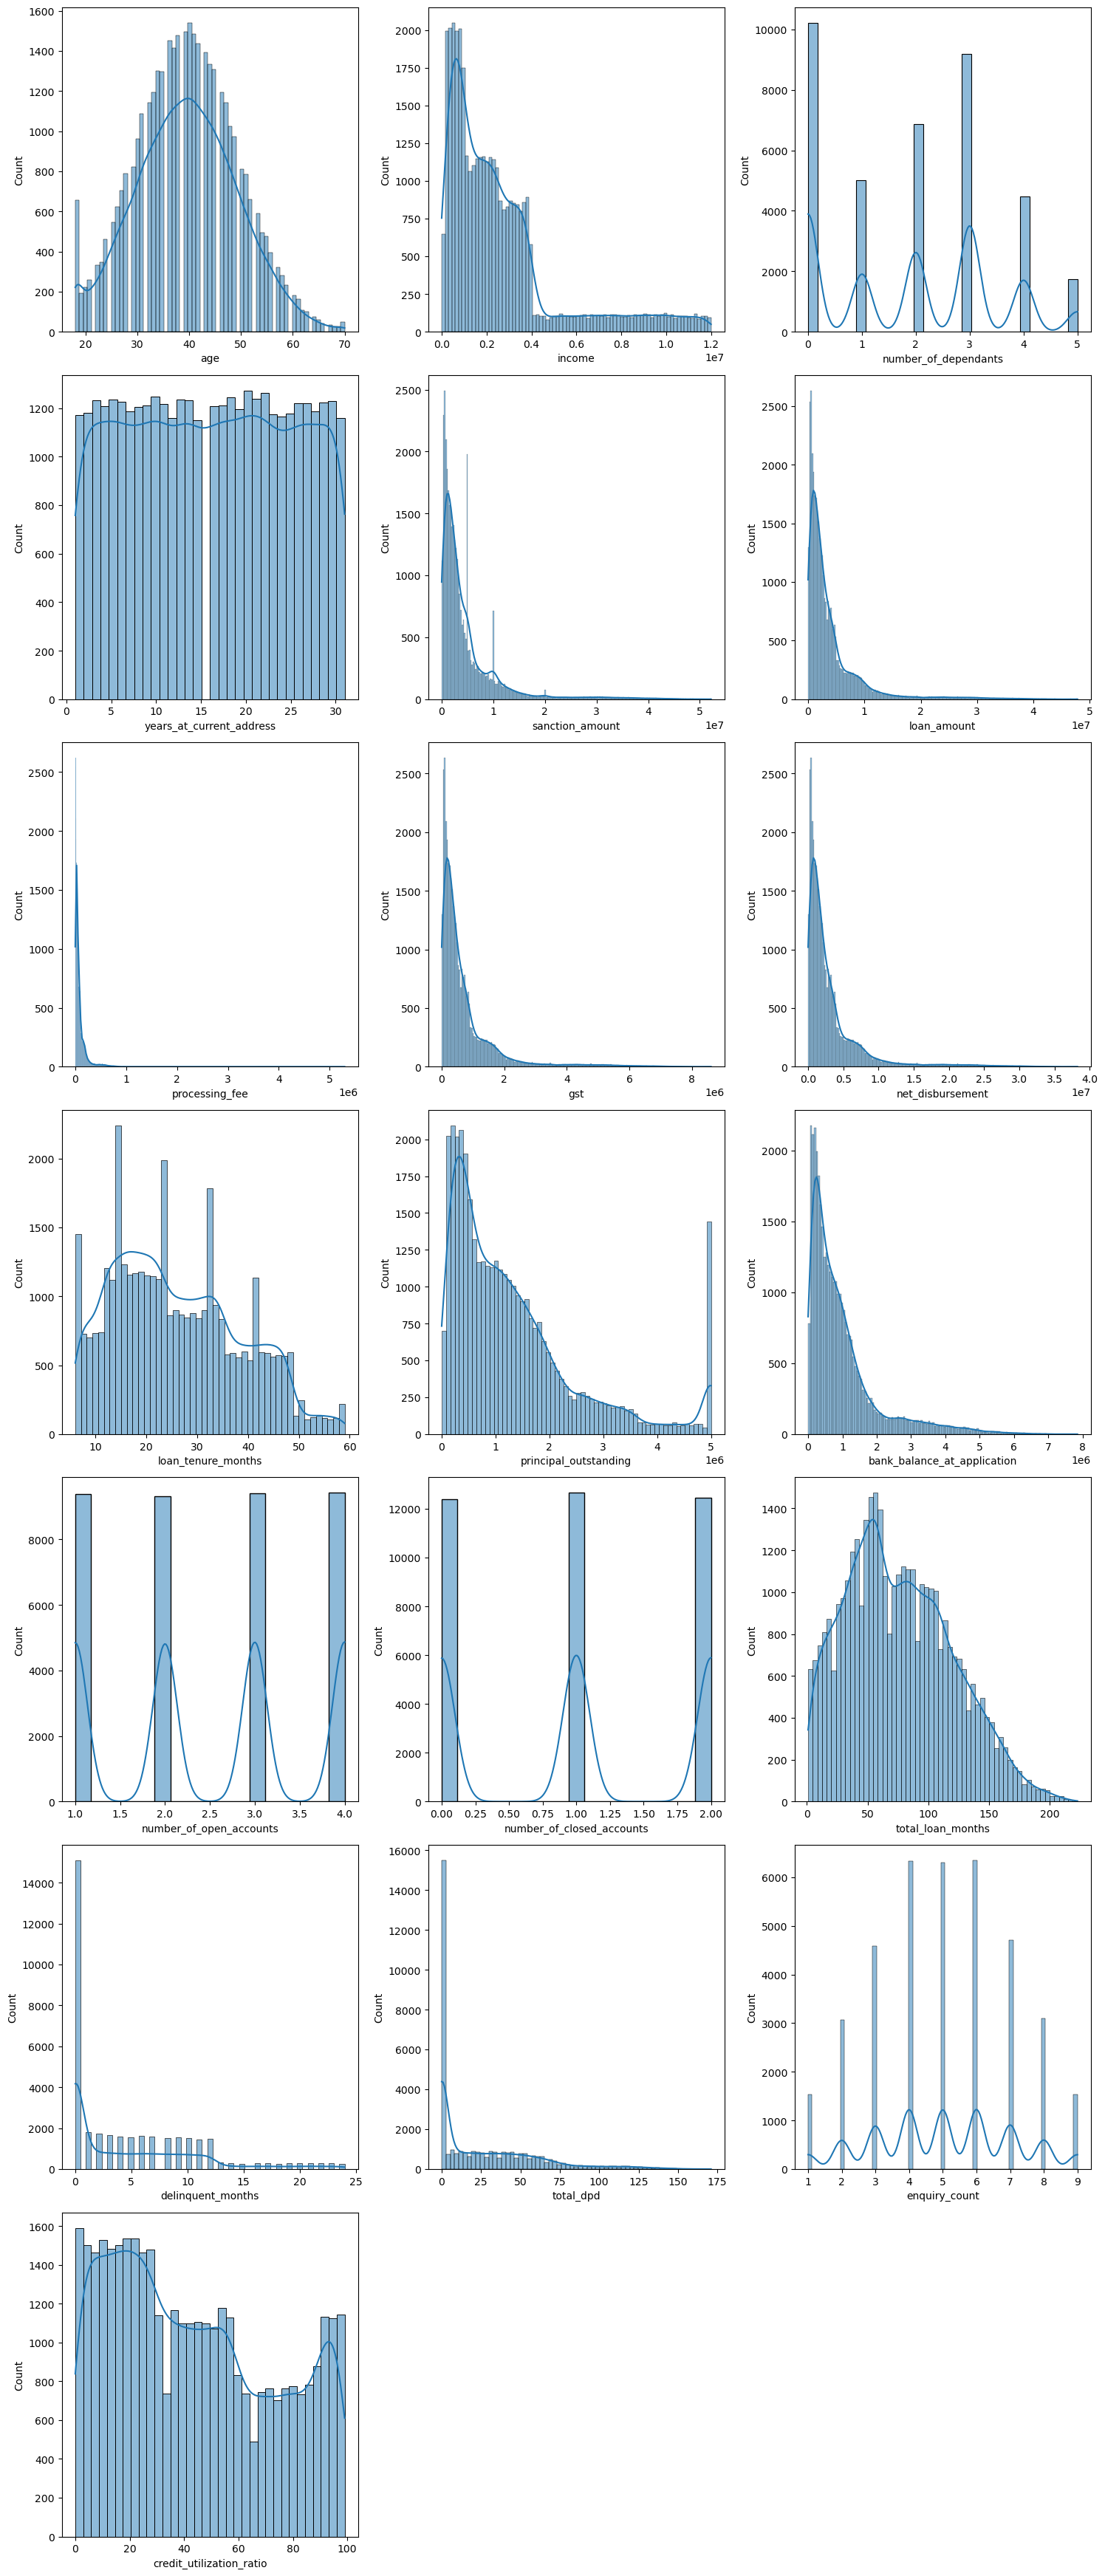

In [27]:
cols=columns_continuous
n_cols=3
n_rows=math.ceil(len(cols)/n_cols)
plt.figure(figsize=(15,5*n_rows))
for i,col in enumerate(cols):
    plt.subplot(n_rows,n_cols,i+1)
    sns.histplot(x=df_train[col],kde=True)
    #plt.title(col)
plt.tight_layout()
plt.show()

We can see that "processing_fee" is heavily right skewed. So thaat can be potential problematic feature which needs further analysis.

#### Outlier Removal: Processing Fee

In [28]:
df_train.processing_fee.describe()

count     37500.00
mean      80290.68
std      113128.14
min           0.00
25%       19220.00
50%       44600.00
75%       92420.00
max     5293543.52
Name: processing_fee, dtype: float64

In [29]:
df_train[df_train["processing_fee"]==df_train.processing_fee.max()][["loan_amount","processing_fee"]]

,loan_amount,processing_fee
9898,3626000,5293543.52


From above we can see that there is clearly a problem because processing fee is greater than loan amount.

In [30]:
df_train[df_train["processing_fee"]>df_train.loan_amount][["loan_amount","processing_fee"]]

,loan_amount,processing_fee
23981,2234000,2669791.02
28174,966000,1214492.67
47089,1738000,1858964.77
29305,2616000,3036378.01
9898,3626000,5293543.52


Suppose the business team says the processing fee is usually  2-3% of loan amount, the above values are certainly above that.

In [31]:
df_train[(df_train["processing_fee"]/df_train.loan_amount)>0.03][["loan_amount","processing_fee"]]

,loan_amount,processing_fee
23981,2234000,2669791.02
28174,966000,1214492.67
47089,1738000,1858964.77
29305,2616000,3036378.01
9898,3626000,5293543.52


Since its just 5 records, we will ignore it

In [32]:
df_train1=df_train[(df_train["processing_fee"]/df_train.loan_amount)<0.03].copy()

In [33]:
df_test=df_test[(df_test["processing_fee"]/df_test.loan_amount)<0.03].copy()
df_test.shape

(12497, 33)

In [34]:
# Use other business rules for data validation
# Rule 1: GST should not be more than 20%

df_train1[(df_train1.gst/df_train1.loan_amount)>0.2].shape

(0, 33)

In [35]:
# Rule 2: Net disbursement should not be higher than loan_amount
df_train1[df_train1.net_disbursement>df_train1.loan_amount].shape

(0, 33)

No rows found that breaks rule 1 and rule 2

#### Analyze Categorical Columns

In [36]:
for col in columns_categorical:
    print(col,": ",df_train1[col].unique() )

gender :  ['M' 'F']
marital_status :  ['Married' 'Single']
employment_status :  ['Self-Employed' 'Salaried']
residence_type :  ['Owned' 'Mortgage' 'Rented']
city :  ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state :  ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
zipcode :  [500001 400001 600001 560001 411001 700001 380001 110001 226001 302001]
loan_purpose :  ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type :  ['Secured' 'Unsecured']
default :  [0 1]


#### Fix Errors in Loan Purpose Column

In [37]:
df_train1["loan_purpose"]=df_train1["loan_purpose"].replace("Personaal","Personal")
df_test["loan_purpose"]=df_test["loan_purpose"].replace("Personaal","Personal")

In [38]:
df_train1["loan_purpose"].unique()

array(['Home', 'Education', 'Personal', 'Auto'], dtype=object)

In [39]:
columns_continuous

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio']

#### Age Column

In [40]:
df_train1.groupby("default")['age'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,34265.00,39.77,9.88,18.00,33.00,40.00,46.00,70.00
1,3223.00,37.12,9.29,18.00,31.00,37.00,44.00,70.00


**Insights**

1. Average age in the default group is little less (37.12) than the average (39.7) of the group that did not default
1. Variability (standard deviation) is mostly similar in both the groups
1. Both the groups have similar min and max ages

<Axes: xlabel='age', ylabel='Density'>

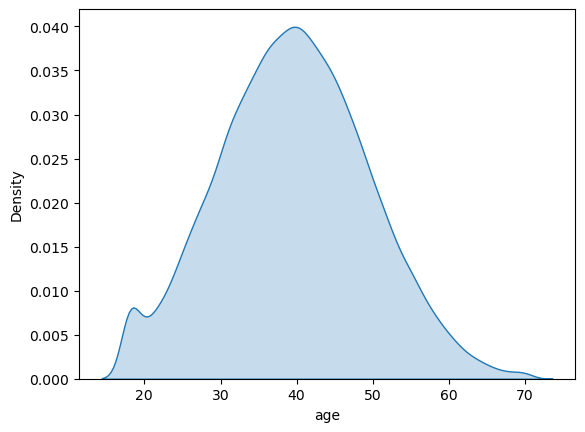

In [41]:
sns.kdeplot(df_train1["age"],fill=True,)

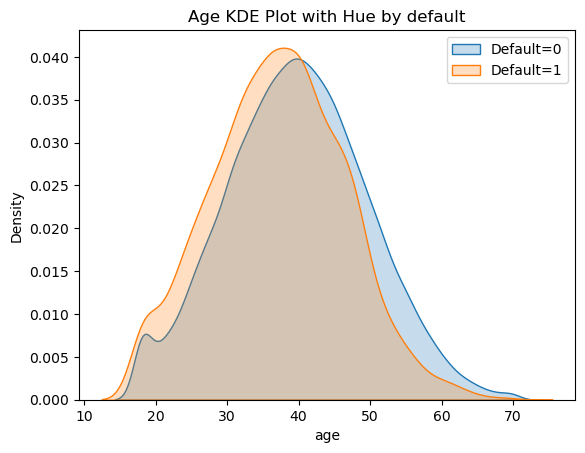

In [42]:
sns.kdeplot(df_train1[df_train1["default"]==0]["age"],fill=True,label="Default=0")
sns.kdeplot(df_train1[df_train1["default"]==1]["age"],fill=True,label="Default=1")
plt.title(f"Age KDE Plot with Hue by default")
plt.legend()
plt.show()

Insights:
1. Orange graph is shifted little bit to the left and blue graph is shifted to the right which indicates people of younger age are more likely to default.

#### KDE for all the Columns

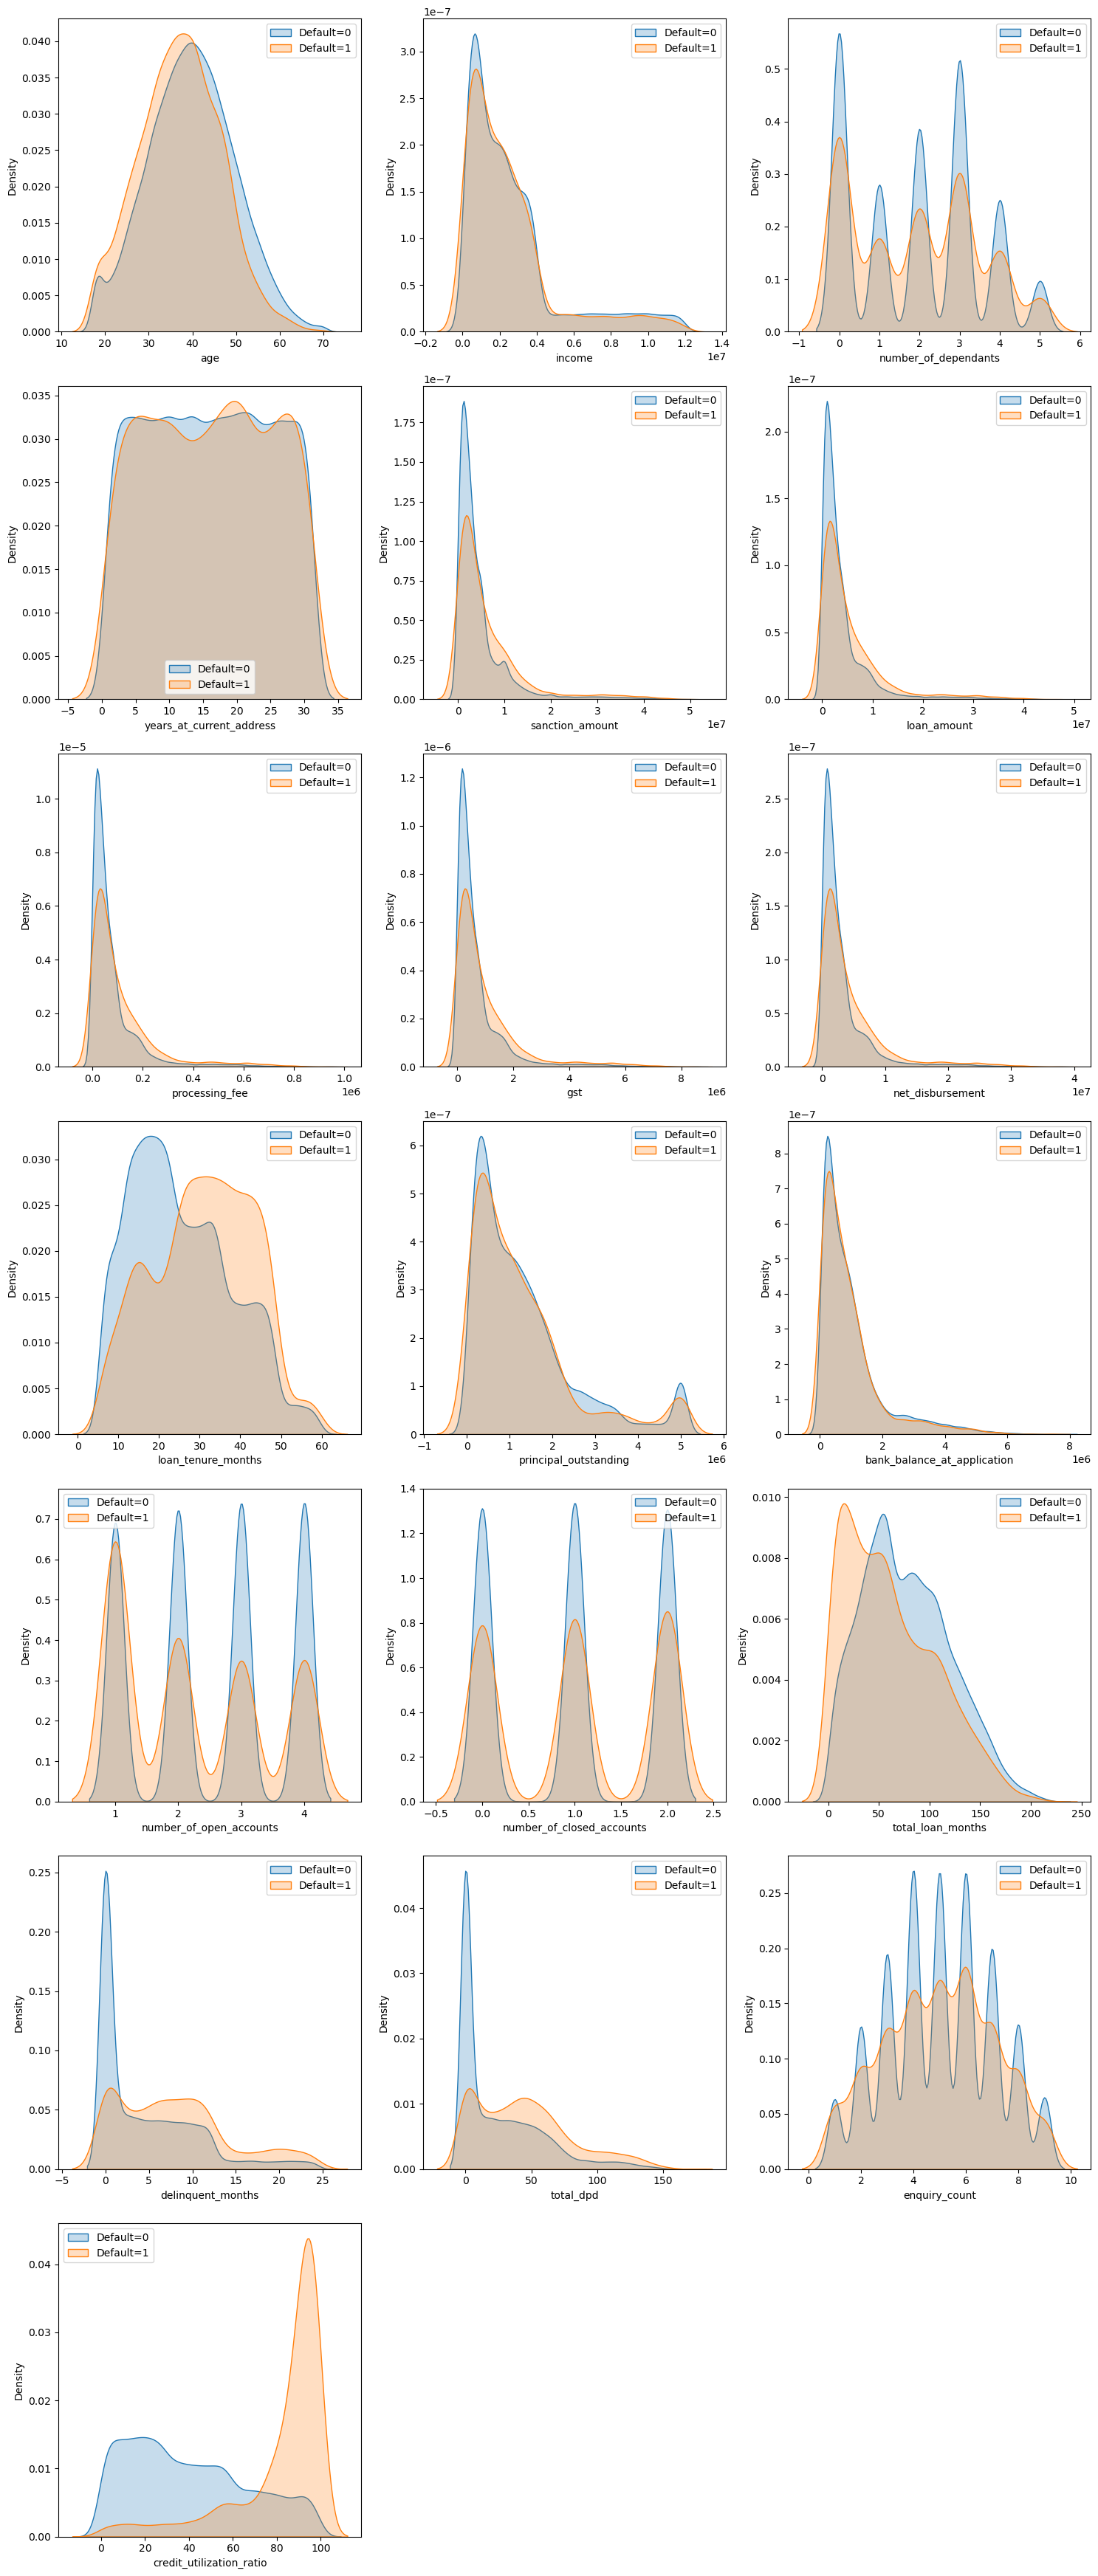

In [43]:
cols=columns_continuous
n_cols=3
n_rows=math.ceil(len(cols)/n_cols)
plt.figure(figsize=(15,5*n_rows))
for i,c in enumerate(cols):
    plt.subplot(n_rows,n_cols,i+1)
    sns.kdeplot(df_train1[df_train1["default"]==0][c],fill=True,label="Default=0")
    sns.kdeplot(df_train1[df_train1["default"]==1][c],fill=True,label="Default=1")
    plt.legend()
plt.tight_layout()
plt.show()

**Insights**

1. In columns: loan_tenure_months, delinquent_months, total_dpd, credit_utilization, higher values indicate high likelyhood of becoming a default. Hence these 4 looks like strong predictors
1. In remaining columns the distributions do not give any obvious insights
1. Why loan_amount and income did not give any signs of being strong predictors? May be when we combine these two and get loan to income ratio (LTI), that may have influence on the target variable. We will explore more later

<h1 align="center">Feature Engineering, Feature Selection</h1>

#### Generate Loan to Income (LTI) Ratio

In [44]:
df_train1["loan_to_income"]=round(df_train1["loan_amount"]/df_train1["income"],2)
df_train1.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default,loan_to_income
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,2020-11-11,4,2,152,20,118,4,36,0,2.07
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,2022-10-27,3,1,160,10,62,5,5,0,1.61
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,...,2023-12-29,1,1,54,12,67,4,0,0,3.54
9040,C09041,42,M,Married,Salaried,1500000,2,Mortgage,30,Bangalore,...,2020-07-07,3,0,76,0,0,8,87,0,1.13
13077,C13078,58,M,Married,Self-Employed,1817000,4,Owned,29,Pune,...,2020-12-07,1,2,60,0,0,1,71,0,0.50


In [45]:
df_train1['loan_to_income'].describe()

count   37488.00
mean        1.56
std         0.97
min         0.30
25%         0.77
50%         1.16
75%         2.46
max         4.57
Name: loan_to_income, dtype: float64

In [46]:
df_test["loan_to_income"]=round(df_test["loan_amount"]/df_test["income"],2)

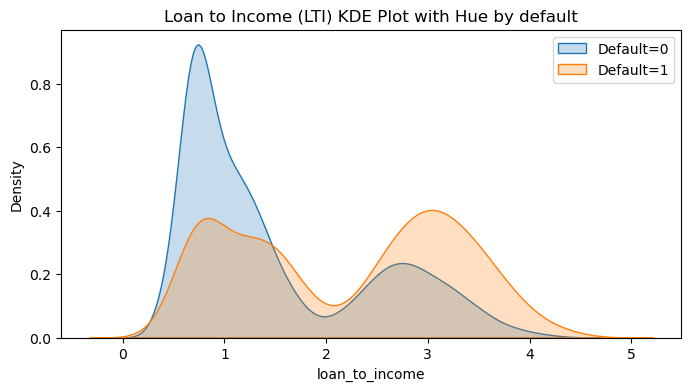

In [47]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train1[df_train1["default"]==0]["loan_to_income"],fill=True,label="Default=0")
sns.kdeplot(df_train1[df_train1["default"]==1]["loan_to_income"],fill=True,label="Default=1")
plt.title(f"Loan to Income (LTI) KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**
1. Blue graph has majority of its values on lower side of LTI
2. Orange graph has many values when LTI is higher indicating that higher LTI means high risk loan

#### Generate Delinquency Ratio

In [48]:
df_train1["delinquency_ratio"]=round((df_train1["delinquent_months"]*100/df_train1["total_loan_months"]),1)
df_train1[["delinquent_months","total_loan_months","delinquency_ratio"]].head(3)

,delinquent_months,total_loan_months,delinquency_ratio
12746,20,152,13.20
32495,10,160,6.20
43675,12,54,22.20


In [49]:
df_test["delinquency_ratio"]=round((df_test["delinquent_months"]*100/df_test["total_loan_months"]),1)
df_test[["delinquent_months","total_loan_months","delinquency_ratio"]].head(3)

,delinquent_months,total_loan_months,delinquency_ratio
19205,0,42,0.00
15514,0,125,0.00
30367,0,76,0.00


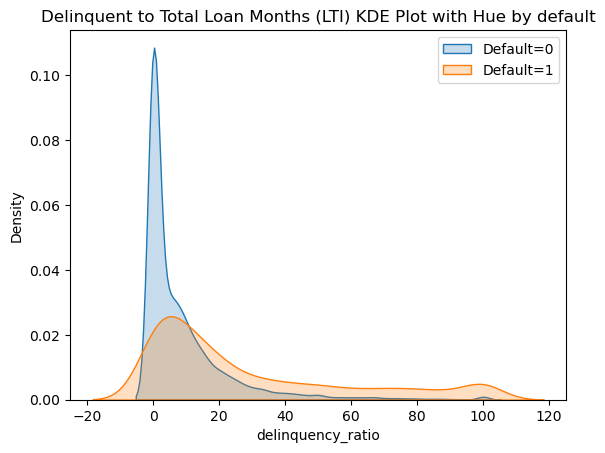

In [50]:
sns.kdeplot(df_train1[df_train1["default"]==0]["delinquency_ratio"],fill=True,label="Default=0")
sns.kdeplot(df_train1[df_train1["default"]==1]["delinquency_ratio"],fill=True,label="Default=1")
plt.title(f"Delinquent to Total Loan Months (LTI) KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**
1. Blue graph has majority of its values on lower side of LTI
2. Orange graph has many values when delinquency ratio is higher indicating some correlation on default

#### Generate Avg DPD Per Delinquency

In [51]:
df_train1["avg_dpd_per_deliquency"]=np.where(
    df_train1["delinquent_months"]!=0,
    (df_train1["total_dpd"]/df_train1["delinquent_months"]).round(1),
    0)


In [52]:
df_test["avg_dpd_per_deliquency"]=np.where(
    df_test["delinquent_months"]!=0,
    (df_test["total_dpd"]/df_test["delinquent_months"]).round(1),
    0)

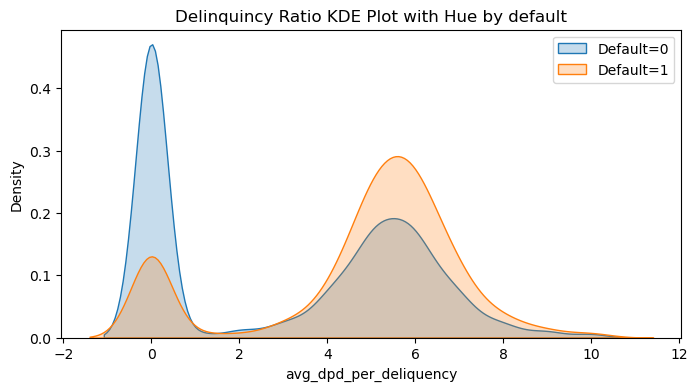

In [53]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train1[df_train1["default"]==0]["avg_dpd_per_deliquency"],fill=True,label="Default=0")
sns.kdeplot(df_train1[df_train1["default"]==1]["avg_dpd_per_deliquency"],fill=True,label="Default=1")
plt.title(f"Delinquincy Ratio KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**

1. Graph clearly shows more occurances of default cases when avg_dpd_per_delinquency is high. This means this column is a strong predictor

#### Remove columns that are just unique ids and don't have influence on target

In [54]:
df_train2=df_train1.drop(["cust_id","loan_id"],axis=1)
df_test=df_test.drop(["cust_id","loan_id"],axis=1)

#### Remove columns that are not relevant for business decision-making

In [55]:
df_train3=df_train2.drop(["disbursal_date","installment_start_dt","loan_amount",
                          "income","total_loan_months","delinquent_months","total_dpd"],axis=1)
df_test=df_test.drop(["disbursal_date","installment_start_dt","loan_amount",
                          "income","total_loan_months","delinquent_months","total_dpd"],axis=1)

In [56]:
df_train3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_deliquency'],
      dtype='object')

In [57]:
df_train3.select_dtypes(["int64","float64"]).columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_deliquency'],
      dtype='object')

#### VIF to measure multicolinearity

In [58]:
X_train=df_train3.drop("default",axis=1)
y_train=df_train3["default"]

##### Scaling Numerical Values

In [59]:
cols_to_scale=X_train.select_dtypes(["int64","float64"]).columns
scaler=MinMaxScaler()
X_train[cols_to_scale]=scaler.fit_transform(X_train[cols_to_scale])

In [60]:
X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_deliquency
count,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00
mean,0.41,0.39,0.50,0.52,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.10,0.33
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00
50%,0.40,0.40,0.50,0.49,0.05,0.05,0.05,0.05,0.34,0.19,0.08,0.67,0.50,0.50,0.39,0.20,0.04,0.43
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.35,0.16,1.00,1.00,0.62,0.68,0.51,0.13,0.57
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


##### Same transformation on test set

In [61]:
x_test=df_test.drop("default",axis=1)
y_test=df_test["default"]

x_test[cols_to_scale]=scaler.transform(x_test[cols_to_scale])
x_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_deliquency
count,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00
mean,0.42,0.38,0.50,0.53,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.11,0.33
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.25,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29
min,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00
50%,0.42,0.40,0.50,0.51,0.05,0.05,0.05,0.05,0.34,0.20,0.08,0.33,0.50,0.50,0.39,0.20,0.04,0.44
75%,0.54,0.60,0.77,0.76,0.10,0.09,0.09,0.09,0.55,0.36,0.16,0.67,1.00,0.62,0.68,0.50,0.13,0.58
max,1.00,1.00,1.00,1.00,0.98,0.96,0.96,0.96,1.00,1.00,0.94,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [62]:
def calculate_vif(data):
    vif_df=pd.DataFrame()
    vif_df["Columns"]=data.columns
    vif_df["VIF"]=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [63]:
calculate_vif(X_train[cols_to_scale])

C:\Users\elzab\anaconda3\envs\ds_env\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Columns,VIF
0,age,5.70
1,number_of_dependants,2.73
2,years_at_current_address,3.42
3,zipcode,3.80
4,sanction_amount,101.09
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.18
9,principal_outstanding,16.33


**The suspicious cluster**

These are the problem variables:

| Feature | VIF |
|---------|-----|
| sanction_amount | 101 |
| processing_fee | inf |
| gst | inf |
| net_disbursement | inf |
| principal_outstanding | 16.33 |

That infinite VIF means:

$R^2 = 1$

The feature can be perfectly reconstructed from the others.

In [64]:
features_to_drop_vif=["sanction_amount","processing_fee","gst","net_disbursement","principal_outstanding"]
X_train1=X_train.drop(features_to_drop_vif,axis=1)

In [65]:
numeric_columns=X_train1.select_dtypes(['int64','float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_deliquency'],
      dtype='object')

In [66]:
vif_df=calculate_vif(X_train1[numeric_columns])
vif_df

,Columns,VIF
0,age,5.43
1,number_of_dependants,2.73
2,years_at_current_address,3.40
3,zipcode,3.78
4,loan_tenure_months,6.02
5,bank_balance_at_application,1.80
6,number_of_open_accounts,4.35
7,number_of_closed_accounts,2.37
8,enquiry_count,6.38
9,credit_utilization_ratio,2.92


In [67]:
selected_numeric_features_vif=vif_df.Columns.values
selected_numeric_features_vif

array(['age', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'enquiry_count', 'credit_utilization_ratio', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_deliquency'], dtype=object)

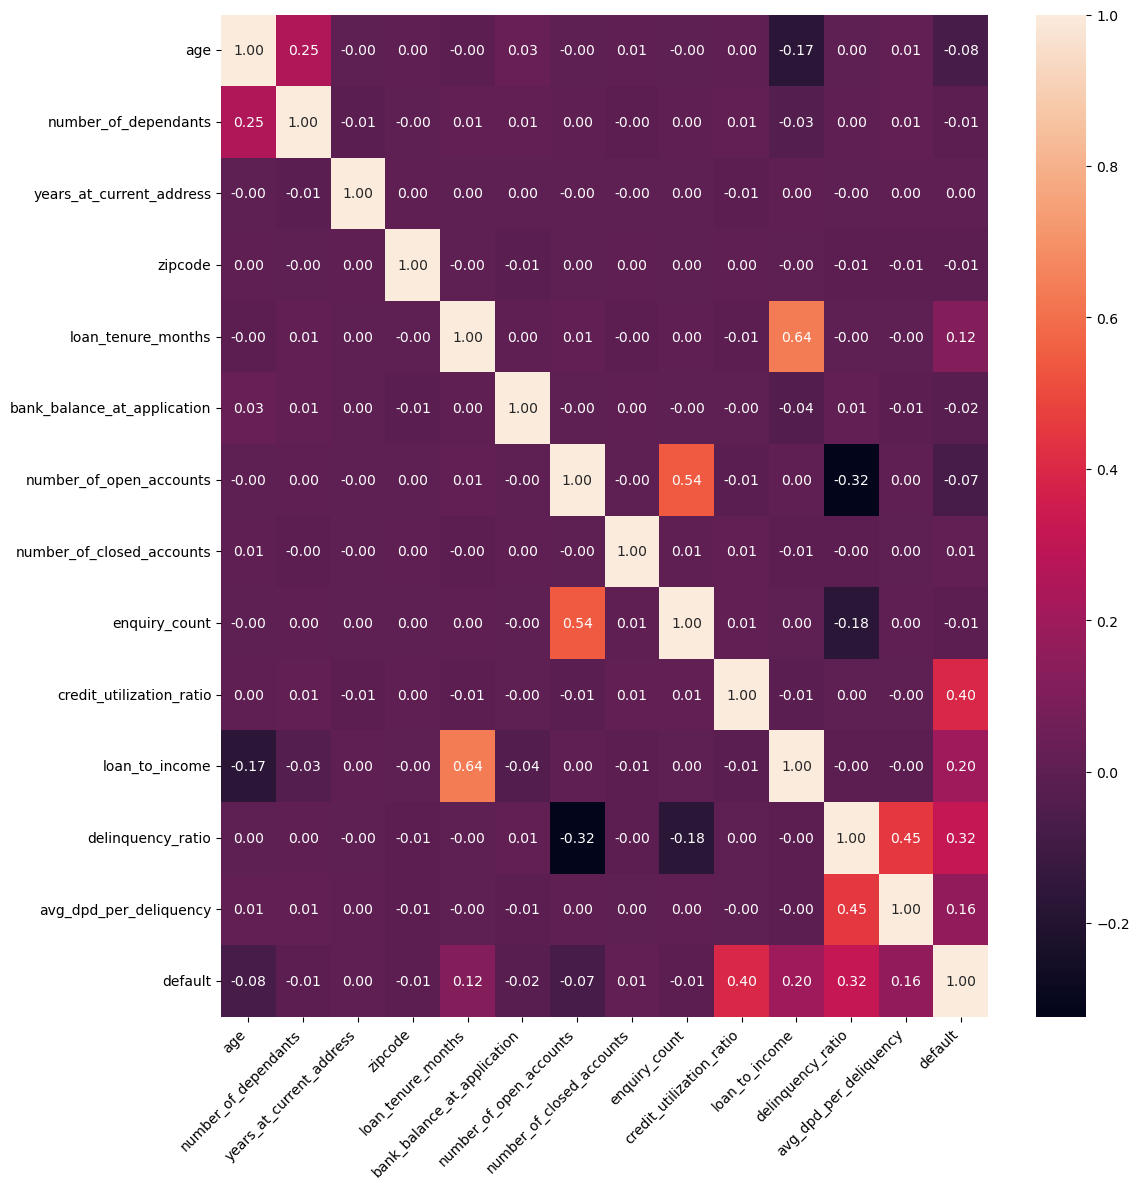

In [68]:
plt.figure(figsize=(12,12))
cm = df_train3[numeric_columns.append(pd.Index(['default']))].corr()
sns.heatmap(cm, annot=True, fmt='0.2f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Feature Selection for Categorical Variables

In [69]:
columns_categorical

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type',
 'default']

##### 🔍 Why WOE (Weight of Evidence)?

WOE is widely used in credit risk modeling because it:
- Creates a monotonic relationship between predictors and the target variable  
- Handles categorical variables effectively  
- Improves interpretability of models like Logistic Regression  

##### 📊 Why IV (Information Value)?

IV helps in:
- Measuring predictive power of features  
- Selecting important variables  
- Eliminating weak or irrelevant features  

##### 📌 Interpretation of IV Values

- IV < 0.02 → Weak predictor  
- 0.02 ≤ IV < 0.1 → Medium predictor  
- 0.1 ≤ IV < 0.3 → Strong predictor  
- IV ≥ 0.3 → Very strong predictor  

WOE transformation was applied to selected features to enhance model performance and interpretability.

In [70]:
def calculate_woe_iv(df,feature,target):
    grouped=df.groupby(feature)[target].agg(['count','sum'])
    grouped=grouped.rename(columns={
        'count':'total',
        'sum':'good'
    })
    grouped["bad"]=grouped["total"]-grouped["good"]
    
    total_good=grouped['good'].sum()
    total_bad=grouped['bad'].sum()
    
    grouped["good_pct"]=(grouped["good"])/total_good
    grouped["bad_pct"]=(grouped["bad"])/total_bad
    
    grouped["woe"]=np.log(grouped["good_pct"]/grouped["bad_pct"])
    grouped["iv"]=(grouped["good_pct"]-grouped["bad_pct"])*grouped["woe"]
    
    grouped["woe"]=grouped["woe"].replace([np.inf,-np.inf],0)
    grouped["iv"]=grouped["iv"].replace([np.inf,-np.inf],0)
    
    total_iv=grouped["iv"].sum()
    
    return grouped,total_iv

In [71]:
grouped, total_iv = calculate_woe_iv(pd.concat([X_train1, y_train],axis=1), 'loan_purpose', 'default')
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,
Auto,7447,327,7120,0.10,0.21,-0.72,0.08
Education,5620,559,5061,0.17,0.15,0.16,0.00
Home,11304,1734,9570,0.54,0.28,0.66,0.17
Personal,13117,603,12514,0.19,0.37,-0.67,0.12


In [72]:
total_iv

0.3691197842282755

In [73]:
X_train1.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_deliquency'],
      dtype='object')

In [74]:
iv_values={}

for feature in X_train1.columns:
    if X_train1[feature].dtype=="object":
        _,iv=calculate_woe_iv(pd.concat([X_train1, y_train],axis=1),feature,"default")
    else:
        X_binned=pd.cut(X_train1[feature],bins=10,labels=False)
        _,iv=calculate_woe_iv(pd.concat([X_binned,y_train],axis=1),feature,"default")
    iv_values[feature]=iv
    
iv_values

{'age': 0.0890689462679479,
 'gender': 0.00047449502170914947,
 'marital_status': 0.001129766845390142,
 'employment_status': 0.003953046301722585,
 'number_of_dependants': 0.0019380899135053508,
 'residence_type': 0.246745268718145,
 'years_at_current_address': 0.0020800513608156363,
 'city': 0.0019059578709781529,
 'state': 0.0019005589806779287,
 'zipcode': 0.0016677413243392572,
 'loan_purpose': 0.3691197842282755,
 'loan_type': 0.16319324904149224,
 'loan_tenure_months': 0.21893515090196278,
 'bank_balance_at_application': 0.0063187993277516365,
 'number_of_open_accounts': 0.08463134083005877,
 'number_of_closed_accounts': 0.0011964272592421567,
 'enquiry_count': 0.007864214085342608,
 'credit_utilization_ratio': 2.352965568168245,
 'loan_to_income': 0.476415456948364,
 'delinquency_ratio': 0.716576108689321,
 'avg_dpd_per_deliquency': 0.40151905412190175}

In [75]:
pd.set_option('display.float_format',lambda x: '{:.3f}'.format(x))

iv_df=pd.DataFrame(list(iv_values.items()),columns=["Feature","IV"])
iv_df=iv_df.sort_values(by="IV",ascending=False)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.353
19,delinquency_ratio,0.717
18,loan_to_income,0.476
20,avg_dpd_per_deliquency,0.402
10,loan_purpose,0.369
5,residence_type,0.247
12,loan_tenure_months,0.219
11,loan_type,0.163
0,age,0.089
14,number_of_open_accounts,0.085


In [76]:
# select features that has IV > 0.02
selected_features_iv=iv_df[iv_df["IV"]>0.02]["Feature"]
selected_features_iv

17    credit_utilization_ratio
19           delinquency_ratio
18              loan_to_income
20      avg_dpd_per_deliquency
10                loan_purpose
5               residence_type
12          loan_tenure_months
11                   loan_type
0                          age
14     number_of_open_accounts
Name: Feature, dtype: object

#### Feature Encoding

In [77]:
X_train_reduced=X_train1[selected_features_iv]
x_test_reduced=x_test[selected_features_iv]

In [78]:
X_train_encoded=pd.get_dummies(X_train_reduced,drop_first=True)
X_test_encoded=pd.get_dummies(x_test_reduced,drop_first=True)

In [79]:
X_train_encoded.head()

,credit_utilization_ratio,delinquency_ratio,loan_to_income,avg_dpd_per_deliquency,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
12746,0.364,0.132,0.415,0.590,0.415,0.788,1.000,False,True,False,True,False,False
32495,0.051,0.062,0.307,0.620,0.830,0.500,0.667,True,False,False,True,False,False
43675,0.000,0.222,0.759,0.560,0.491,0.385,0.000,False,True,False,False,False,False
9040,0.879,0.000,0.194,0.000,0.642,0.462,0.667,True,False,False,False,False,False
13077,0.717,0.000,0.047,0.000,0.170,0.769,0.000,False,False,True,True,False,True


<h1 align="center"> Model Training</h1>

#### Attempt 1

1. Logistic Regression, Random Forest and XGB
2. No handling of class Imbalance

In [80]:
model=LogisticRegression()
model.fit(X_train_encoded,y_train)

y_pred=model.predict(X_test_encoded)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.72      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



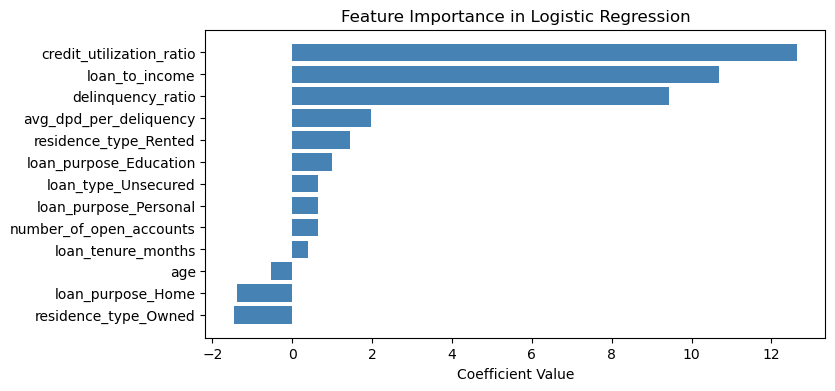

In [81]:
feature_importance = model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [82]:
model=RandomForestClassifier()
model.fit(X_train_encoded,y_train)
y_pred=model.predict(X_test_encoded)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.72      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [83]:
model=XGBClassifier()
model.fit(X_train_encoded,y_train)
y_pred=model.predict(X_test_encoded)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.82      0.76      0.79      1074

    accuracy                           0.97     12497
   macro avg       0.90      0.87      0.89     12497
weighted avg       0.96      0.97      0.96     12497



Since there is not much difference between XGB and Logistic, we will choose LogisticRegression as a candidate for our RandomizedSearchCV candidate it has a better interpretation.

#### RandomizedSearch CV for Attempt 1: Logistic Regression

In [84]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': np.logspace(-4, 4, 20),  # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']   # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000)  # Increased max_iter for convergence

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled
    scoring='f1',
    cv=3,  # 5-fold cross-validation
    verbose=2,
    random_state=42,  # Set a random state for reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the RandomizedSearchCV to the training data
random_search.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'liblinear', 'C': 1438.44988828766}
Best Score: 0.7578820896729832
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11423
           1       0.83      0.74      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.86      0.88     12497
weighted avg       0.96      0.96      0.96     12497



Recall hasnt improved much

#### RandomizedSearch CV for Attempt 1: XGBoost

In [85]:
# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # L1 regularization term
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]  # L2 regularization term
}


In [86]:
xgb=XGBClassifier()

In [87]:
random_search=RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=100,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [88]:
random_search.fit(X_train_encoded,y_train)

#Print Best Parameters and Best Scores

print(f"Best Parameters : {random_search.best_params_}")
print(f"Best Scores : {random_search.best_score_}")

best_model=random_search.best_estimator_

y_pred=best_model.predict(X_test_encoded)
report=classification_report(y_test,y_pred)
print(report)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters : {'subsample': 0.8, 'scale_pos_weight': 2, 'reg_lambda': 1.0, 'reg_alpha': 5.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best Scores : 0.7899576028706171
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.77      0.83      0.80      1074

    accuracy                           0.96     12497
   macro avg       0.88      0.90      0.89     12497
weighted avg       0.97      0.96      0.96     12497



we can see f1 hs improved. recall has also improved.

<h3> Attempt 2 </h3>

1. Logistic Regression and XGB
2. Handle Class Imbalance using Under Sampling

In [91]:
rus=RandomUnderSampler(random_state=42)
X_train_rus,y_train_rus=rus.fit_resample(X_train_encoded,y_train)
y_train_rus.value_counts()

default
0    3223
1    3223
Name: count, dtype: int64

In [92]:
model=LogisticRegression()
model.fit(X_train_rus,y_train_rus)

y_pred=model.predict(X_test_encoded)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.51      0.96      0.67      1074

    accuracy                           0.92     12497
   macro avg       0.75      0.93      0.81     12497
weighted avg       0.95      0.92      0.93     12497



In [93]:
model = XGBClassifier(**random_search.best_params_)
model.fit(X_train_rus, y_train_rus)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.51      0.98      0.67      1074

    accuracy                           0.92     12497
   macro avg       0.75      0.95      0.81     12497
weighted avg       0.96      0.92      0.93     12497



Now we can see recll has improved for default class.

<h3>Attempt 3</h3>

1. Logistic Regression

2. Handle class imbalance using SMOTE Tomek

3. Parameter tuning using Optuna

In [94]:
smt=SMOTETomek(random_state=42)
X_train_smt,y_train_smt=smt.fit_resample(X_train_encoded,y_train)
y_train_smt.value_counts()

default
0    34195
1    34195
Name: count, dtype: int64

In [95]:
model=LogisticRegression()
model.fit(X_train_smt,y_train_smt)

y_pred=model.predict(X_test_encoded)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.55      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



Here we can see we improved recall.

### Parameter Tuning using Optuna

In [127]:
def objective(trial):
    param = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Logarithmically spaced values
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']),  # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Logarithmically spaced values for tolerance
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class weights
    }

    model = LogisticRegression(**param, max_iter=10000)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)




In [128]:
study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50)


[I 2026-03-29 21:07:18,083] A new study created in memory with name: no-name-786303bf-b9d0-4c9c-96ae-6bc4a20aed71
[I 2026-03-29 21:07:20,878] Trial 0 finished with value: 0.9102449434274115 and parameters: {'C': 0.001400550906224809, 'solver': 'saga', 'tol': 0.028383672209146556, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9102449434274115.
[I 2026-03-29 21:07:23,806] Trial 1 finished with value: 0.9456354327232822 and parameters: {'C': 47.564074049524024, 'solver': 'saga', 'tol': 6.069941922524657e-06, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9456354327232822.
[I 2026-03-29 21:07:26,786] Trial 2 finished with value: 0.9456794085990863 and parameters: {'C': 7708.9181970456875, 'solver': 'saga', 'tol': 0.00018901905144757123, 'class_weight': None}. Best is trial 2 with value: 0.9456794085990863.
[I 2026-03-29 21:07:29,560] Trial 3 finished with value: 0.8388806863569326 and parameters: {'C': 0.00038045031207575435, 'solver': 'liblinear', 'tol': 6.5859397

[I 2026-03-29 21:07:37,087] Trial 32 finished with value: 0.9456794085990863 and parameters: {'C': 1472.475144693863, 'solver': 'liblinear', 'tol': 9.641672789295219e-06, 'class_weight': None}. Best is trial 4 with value: 0.9457227803228164.
[I 2026-03-29 21:07:37,433] Trial 33 finished with value: 0.9456500987009903 and parameters: {'C': 126.94720528216409, 'solver': 'liblinear', 'tol': 3.2992159887985455e-06, 'class_weight': None}. Best is trial 4 with value: 0.9457227803228164.
[I 2026-03-29 21:07:37,751] Trial 34 finished with value: 0.9456794085990863 and parameters: {'C': 2933.113106798903, 'solver': 'liblinear', 'tol': 1.749199618107054e-05, 'class_weight': 'balanced'}. Best is trial 4 with value: 0.9457227803228164.
[I 2026-03-29 21:07:38,082] Trial 35 finished with value: 0.9456794085990863 and parameters: {'C': 409.3765935826913, 'solver': 'liblinear', 'tol': 3.2027312135082578e-06, 'class_weight': None}. Best is trial 4 with value: 0.9457227803228164.
[I 2026-03-29 21:07:38,

In [129]:
trial=study_logistic.best_trial

In [130]:
print('Best Trial')
print(' F1-score: {}'.format(trial.value))
print(' Params: ')
for key,value in trial.params.items():
   print('  {}: {}'.format(key,value))



Best Trial
 F1-score: 0.9457227803228164
 Params: 
  C: 9.831663816713506
  solver: saga
  tol: 1.0028296063093671e-06
  class_weight: None


In [131]:
best_model_logistic=LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(X_train_smt,y_train_smt)

#Evaluate on the test set

y_pred=best_model_logistic.predict(X_test_encoded)

report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



<h3> Attempt 4 </h3>

1. XGBoost
2. Handle Class Imbalance using SMOTE Tomek
3. Parameter tuning using Optuna

In [132]:
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'verbosity': 0,
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    model = XGBClassifier(**param)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)




In [133]:
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

[I 2026-03-29 21:11:33,429] A new study created in memory with name: no-name-bd74ae7b-5fb1-4f38-bc93-3fa835363d1d
[I 2026-03-29 21:11:34,191] Trial 0 finished with value: 0.9604095617289025 and parameters: {'lambda': 0.001590835548920993, 'alpha': 0.0425817725903305, 'subsample': 0.77998570160452, 'colsample_bytree': 0.6215062636726937, 'max_depth': 4, 'eta': 0.20458358459388537, 'gamma': 1.0006588532818927, 'scale_pos_weight': 3.8431698204837104, 'min_child_weight': 7, 'max_delta_step': 10}. Best is trial 0 with value: 0.9604095617289025.
[I 2026-03-29 21:11:35,294] Trial 1 finished with value: 0.9724385263841975 and parameters: {'lambda': 0.2393705819703604, 'alpha': 2.783169211580335, 'subsample': 0.6405130272881641, 'colsample_bytree': 0.9959457198244334, 'max_depth': 9, 'eta': 0.2998483860673035, 'gamma': 0.6618386080162519, 'scale_pos_weight': 8.190982010306534, 'min_child_weight': 7, 'max_delta_step': 6}. Best is trial 1 with value: 0.9724385263841975.
[I 2026-03-29 21:11:36,205

[I 2026-03-29 21:11:51,657] Trial 19 finished with value: 0.9720599842783973 and parameters: {'lambda': 0.051525483458589726, 'alpha': 0.31652190140980463, 'subsample': 0.5329161083957905, 'colsample_bytree': 0.8260962716378873, 'max_depth': 9, 'eta': 0.21667902705649827, 'gamma': 3.2399254402658473, 'scale_pos_weight': 2.860034574903672, 'min_child_weight': 8, 'max_delta_step': 2}. Best is trial 11 with value: 0.9748161945990556.
[I 2026-03-29 21:11:52,576] Trial 20 finished with value: 0.9739951256860069 and parameters: {'lambda': 0.4198561852178068, 'alpha': 0.07899514439655043, 'subsample': 0.717209331162426, 'colsample_bytree': 0.8635316462792169, 'max_depth': 7, 'eta': 0.17633534901822076, 'gamma': 1.040705793877177, 'scale_pos_weight': 1.702023674309114, 'min_child_weight': 5, 'max_delta_step': 4}. Best is trial 11 with value: 0.9748161945990556.
[I 2026-03-29 21:11:53,447] Trial 21 finished with value: 0.9737478556023179 and parameters: {'lambda': 0.005798027958411047, 'alpha':

[I 2026-03-29 21:12:09,602] Trial 38 finished with value: 0.9717516711370836 and parameters: {'lambda': 0.007469296692776034, 'alpha': 0.06376742840898866, 'subsample': 0.7667825749935692, 'colsample_bytree': 0.5031720400499579, 'max_depth': 10, 'eta': 0.21154705766034734, 'gamma': 1.2230378009862617, 'scale_pos_weight': 6.857172731397549, 'min_child_weight': 1, 'max_delta_step': 6}. Best is trial 33 with value: 0.974917092368392.
[I 2026-03-29 21:12:10,300] Trial 39 finished with value: 0.9665209136969269 and parameters: {'lambda': 0.19743296952344352, 'alpha': 3.5073462928527017, 'subsample': 0.80190140581064, 'colsample_bytree': 0.7958245084157958, 'max_depth': 8, 'eta': 0.29185250409362407, 'gamma': 7.822302753465134, 'scale_pos_weight': 2.6967760628676083, 'min_child_weight': 6, 'max_delta_step': 9}. Best is trial 33 with value: 0.974917092368392.
[I 2026-03-29 21:12:11,156] Trial 40 finished with value: 0.9704818105879957 and parameters: {'lambda': 1.7483021642217391, 'alpha': 7.

In [134]:
print("Best Trial")
trial=study_xgb.best_trial

print(" F1 Score: {}".format(trial.value))
print(" Params: ")
for key,value in trial.params.items():
    print('  {}: {}'.format(key,value))
    

Best Trial
 F1 Score: 0.974917092368392
 Params: 
  lambda: 0.0023664854629512674
  alpha: 0.4028246387311838
  subsample: 0.7658889703575527
  colsample_bytree: 0.961601067850697
  max_depth: 9
  eta: 0.22724663680787568
  gamma: 1.311657306995622
  scale_pos_weight: 1.8408929392981475
  min_child_weight: 10
  max_delta_step: 5


In [135]:
best_params=study_xgb.best_params

best_model_xgb=XGBClassifier(**best_params)
best_model_xgb.fit(X_train_smt,y_train_smt)

y_pred=best_model_xgb.predict(X_test_encoded)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     11423
           1       0.71      0.87      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.85      0.92      0.88     12497
weighted avg       0.96      0.96      0.96     12497



Campared to logistic model, recall for xgb is lower. So we choose Logistic Regression as the best model.

<h1 align="center"> Model Evaluation</h1>

Evaluating models using ROC-AUC and KS Statistic.

### ROC AUC Curve - Logistic Regression

In [136]:
y_pred=best_model_logistic.predict(X_test_encoded)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [137]:
probabilities=best_model_logistic.predict_proba(X_test_encoded)[:,1]
print(probabilities)

[0.52439723 0.00001006 0.00519905 ... 0.0020653  0.84153008 0.58719793]


In [138]:
fpr,tpr,thresholds=roc_curve(y_test,probabilities)
fpr[:5],tpr[:5],thresholds[:5]

(array([0.        , 0.        , 0.        , 0.00008754, 0.00008754]),
 array([0.        , 0.0009311 , 0.15828678, 0.15828678, 0.17597765]),
 array([       inf, 1.        , 0.999528  , 0.99951109, 0.9993831 ]))

In [139]:
area_log_reg=auc(fpr,tpr)
area_log_reg

0.9836503861740608

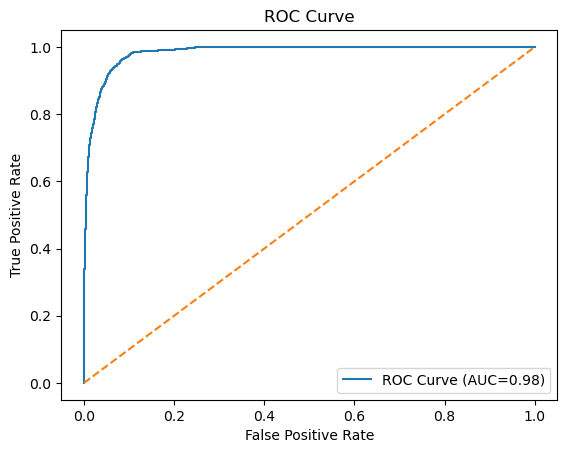

In [140]:
plt.figure()
plt.plot(fpr,tpr,label=f"ROC Curve (AUC={area_log_reg:.2f})")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [141]:
distances = np.sqrt((1 - tpr)**2 + (fpr)**2)
best_idx = np.argmin(distances)

best_threshold = thresholds[best_idx]
best_threshold

0.5396024372937068

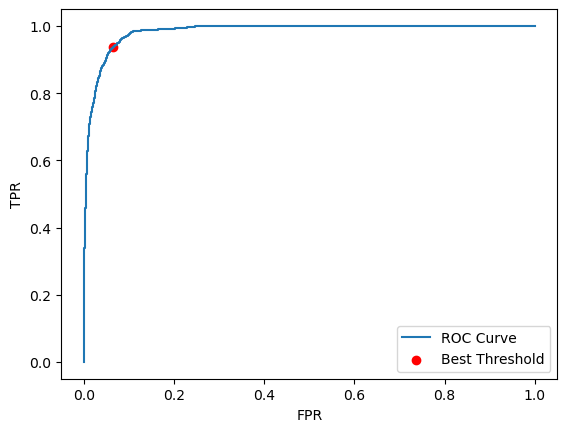

In [142]:
plt.plot(fpr, tpr, label="ROC Curve")
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label='Best Threshold')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

#### ROC AUC Curve - XGBoost

In [143]:
y_pred=best_model_xgb.predict(X_test_encoded)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     11423
           1       0.71      0.87      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.85      0.92      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [144]:
probabilities=best_model_xgb.predict_proba(X_test_encoded)[:,1]
print(probabilities)

[0.46117535 0.00003742 0.00016852 ... 0.00012836 0.24355313 0.20476444]


In [145]:
fpr,tpr,thresholds=roc_curve(y_test,probabilities)
fpr[:5],tpr[:5],thresholds[:5]

(array([0., 0., 0., 0., 0.]),
 array([0.        , 0.0009311 , 0.10614525, 0.10800745, 0.24394786]),
 array([       inf, 0.99993885, 0.99831223, 0.9983076 , 0.99344313],
       dtype=float32))

In [146]:
area_xgb=auc(fpr,tpr)
area_xgb

0.9853863232254961

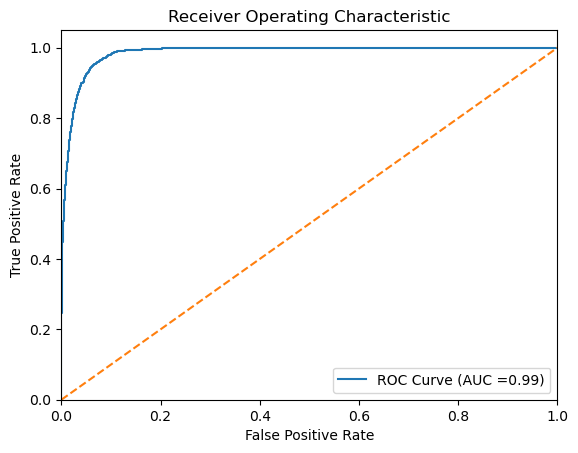

In [147]:
plt.figure()
plt.plot(fpr,tpr,label=f"ROC Curve (AUC ={area_xgb:.2f})")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [148]:
distances = np.sqrt((1 - tpr)**2 + (fpr)**2)
best_idx = np.argmin(distances)

best_threshold = thresholds[best_idx]
best_threshold

0.18792264

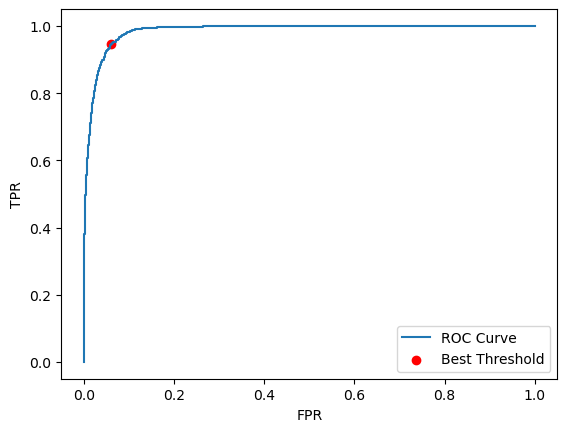

In [157]:
plt.plot(fpr, tpr, label="ROC Curve")
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label='Best Threshold')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

This suggests our Logistic Regression is good

### KS Statistics and Rankholder

KS measures the maximum separation between defaulters and non-defaulters

In [150]:
def ks_value_calculation(y_test,probabilities):
    
    df_eval=pd.DataFrame({
        'Default Truth':y_test,
        'Default Probabilities':probabilities
    })

    df_eval["Decile"]=pd.qcut(df_eval["Default Probabilities"],10,labels=False,duplicates="drop")
    
    df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({
        'Minimum Probability': x['Default Probabilities'].min(),
        'Maximum Probability': x['Default Probabilities'].max(),
        'Events': x['Default Truth'].sum(),
        'Non-events': x['Default Truth'].count() - x['Default Truth'].sum(),    
    }),include_groups=False).reset_index()
   
    df_decile=df_decile.sort_values(by="Decile",ascending=False).reset_index(drop=True)
    
    total_events=df_decile["Events"].sum()
    total_non_events=df_decile["Non-events"].sum()
    
    df_decile["Cum Events"]=df_decile["Events"].cumsum()
    df_decile["Cum Non-Events"]=df_decile["Non-events"].cumsum()
    
    df_decile["Cum % Events"]=(df_decile["Cum Events"]*100)/total_events
    df_decile["Cum % Non-Events"]=(df_decile["Cum Non-Events"]*100)/total_non_events
    
    df_decile["KS"]=abs(df_decile["Cum % Events"]-df_decile["Cum % Non-Events"])
    
    return df_decile

#### Logistic Regression: 

In [151]:
probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]

In [152]:
df_log_reg_decile=ks_value_calculation(y_test,probabilities)
df_log_reg_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Cum Events,Cum Non-Events,Cum % Events,Cum % Non-Events,KS
0,9,0.822,1.000,898.000,352.000,898.000,352.000,83.613,3.082,80.531
1,8,0.210,0.821,161.000,1089.000,1059.000,1441.000,98.603,12.615,85.988
2,7,0.027,0.210,10.000,1239.000,1069.000,2680.000,99.534,23.461,76.073
3,6,0.004,0.027,5.000,1245.000,1074.000,3925.000,100.000,34.361,65.639
4,5,0.001,0.004,0.000,1249.000,1074.000,5174.000,100.000,45.295,54.705
5,4,0.000,0.001,0.000,1250.000,1074.000,6424.000,100.000,56.237,43.763
6,3,0.000,0.000,0.000,1250.000,1074.000,7674.000,100.000,67.180,32.820
7,2,0.000,0.000,0.000,1249.000,1074.000,8923.000,100.000,78.114,21.886
8,1,0.000,0.000,0.000,1250.000,1074.000,10173.000,100.000,89.057,10.943
9,0,0.000,0.000,0.000,1250.000,1074.000,11423.000,100.000,100.000,0.000


#### XGBoost

In [153]:
probabilities = best_model_xgb.predict_proba(X_test_encoded)[:,1]

In [154]:
df_xgb_decile=ks_value_calculation(y_test,probabilities)
df_xgb_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Cum Events,Cum Non-Events,Cum % Events,Cum % Non-Events,KS
0,9,0.573,1.000,914.000,336.000,914.000,336.000,85.102,2.941,82.161
1,8,0.013,0.572,150.000,1100.000,1064.000,1436.000,99.069,12.571,86.498
2,7,0.001,0.013,8.000,1241.000,1072.000,2677.000,99.814,23.435,76.379
3,6,0.000,0.001,2.000,1248.000,1074.000,3925.000,100.000,34.361,65.639
4,5,0.000,0.000,0.000,1249.000,1074.000,5174.000,100.000,45.295,54.705
5,4,0.000,0.000,0.000,1250.000,1074.000,6424.000,100.000,56.237,43.763
6,3,0.000,0.000,0.000,1250.000,1074.000,7674.000,100.000,67.180,32.820
7,2,0.000,0.000,0.000,1249.000,1074.000,8923.000,100.000,78.114,21.886
8,1,0.000,0.000,0.000,1250.000,1074.000,10173.000,100.000,89.057,10.943
9,0,0.000,0.000,0.000,1250.000,1074.000,11423.000,100.000,100.000,0.000


Both models achieved high KS values (~86), indicating strong ability to distinguish between defaulters and non-defaulters. The majority of default cases are concentrated in the top deciles, reflecting effective risk ranking. XGBoost shows only a marginal improvement over Logistic Regression, suggesting that the simpler model is sufficient for this dataset.


### Gini Coefficient

#### Logisitc Regression

In [155]:
gini_coefficient = 2 * area_log_reg - 1

print("AUC:", area_log_reg)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.9836503861740608
Gini Coefficient: 0.9673007723481215


#### XGB

In [156]:
gini_coefficient = 2 * area_xgb - 1

print("AUC:", area_xgb)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.9853863232254961
Gini Coefficient: 0.9707726464509923


### 📊 Model Comparison & Interpretation

| Model               | Recall |ROC-AUC | KS Score  | Gini Coef |
|---------------------|--------|--------|-----------|----------|
| Logistic Regression |  0.94  | 0.98  | 85.9 %     |0.97
| XGBoost             |  0.87  | 0.99  |	86.4 %  |0.97

Both Logistic Regression and XGBoost models demonstrate strong predictive performance, with high ROC-AUC and Gini coefficients, indicating excellent ability to distinguish between defaulters and non-defaulters.

- **XGBoost** achieves slightly higher ROC-AUC (0.99) and KS score (86.49), suggesting better overall separation between good and bad customers.
- **Logistic Regression** achieves significantly higher recall (0.94), meaning it is more effective at identifying defaulters.

Given that credit risk modeling prioritizes minimizing financial loss by correctly identifying high-risk customers, recall is a critical metric.

Additionally, Logistic Regression provides:
- High interpretability  
- Transparency in decision-making  
- Alignment with industry practices in credit risk modeling  

#### 🏆 Final Decision
Logistic Regression was selected as the final model due to its higher recall and interpretability, making it more suitable for real-world financial applications.

In [158]:
feature_importance=best_model_logistic.coef_[0]

coef_df=pd.DataFrame(feature_importance,index=X_train_smt.columns,columns=["Coefficients"])
coef_df=coef_df.sort_values(by="Coefficients",ascending=True)
coef_df

,Coefficients
loan_purpose_Home,-3.663
residence_type_Owned,-1.862
age,0.078
loan_tenure_months,0.641
loan_purpose_Education,0.987
loan_purpose_Personal,1.088
loan_type_Unsecured,1.088
number_of_open_accounts,1.205
residence_type_Rented,1.876
avg_dpd_per_deliquency,2.057


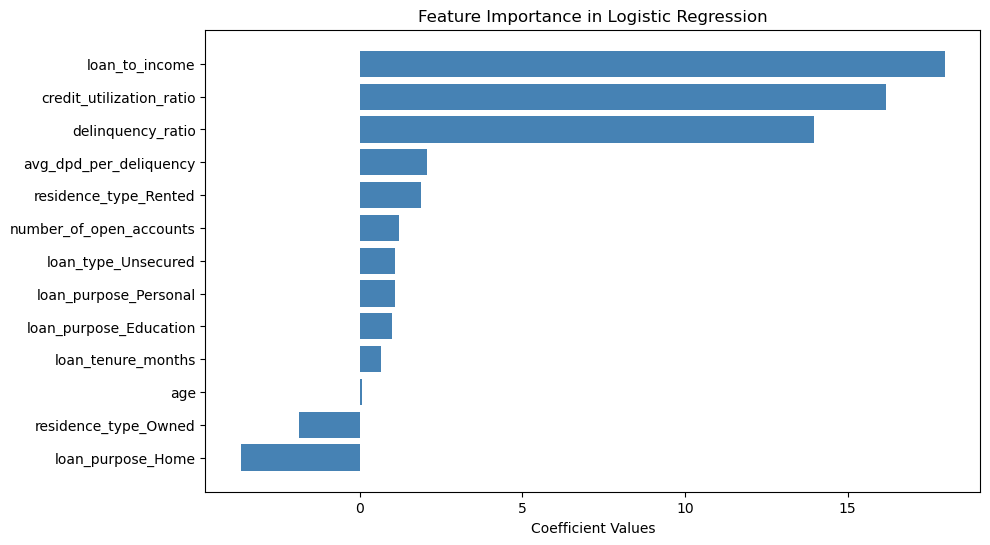

In [159]:
# Plotting

plt.figure(figsize=(10,6))
plt.barh(coef_df.index,coef_df["Coefficients"],color="steelblue")
plt.xlabel("Coefficient Values")
plt.title("Feature Importance in Logistic Regression")
plt.show()

### 🧠 Business Insights

#### 🔴 High Risk Drivers
- Loan-to-income ratio is the strongest predictor of default risk  
- High credit utilization indicates financial stress  
- Past delinquency behavior strongly increases default probability  

#### 🟡 Moderate Risk Factors
- Higher days past due increases risk  
- Customers living in rented properties show slightly higher default risk  

#### 🟢 Lower Risk Indicators
- Home loans are associated with lower default risk  
- Owned residence indicates financial stability  

These findings align with domain knowledge in credit risk modeling and validate the model's behavior.

### Save the Model

In [160]:
X_test_encoded.head(2)

,credit_utilization_ratio,delinquency_ratio,loan_to_income,avg_dpd_per_deliquency,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
19205,0.990,0.000,0.550,0.000,0.755,0.346,0.333,False,True,False,True,False,False
15514,0.323,0.000,0.220,0.000,0.226,0.481,1.000,True,False,False,True,False,False


In [161]:
X_test_encoded.columns

Index(['credit_utilization_ratio', 'delinquency_ratio', 'loan_to_income',
       'avg_dpd_per_deliquency', 'loan_tenure_months', 'age',
       'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [162]:
cols_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_deliquency'],
      dtype='object')

In [163]:
X_train_encoded.columns

Index(['credit_utilization_ratio', 'delinquency_ratio', 'loan_to_income',
       'avg_dpd_per_deliquency', 'loan_tenure_months', 'age',
       'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [164]:
X_train_smt.columns

Index(['credit_utilization_ratio', 'delinquency_ratio', 'loan_to_income',
       'avg_dpd_per_deliquency', 'loan_tenure_months', 'age',
       'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [168]:
from joblib import dump

model_data = {
    'model': best_model_logistic,
    'features': X_train_encoded.columns,
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}
dump(model_data, 'C:/Users/elzab/Documents/Job/Data Science Learn/Project Credit Risk/ML-Project-Credit-Risk-Score/artifacts/model_data.joblib')

['C:/Users/elzab/Documents/Job/Data Science Learn/Project Credit Risk/ML-Project-Credit-Risk-Score/artifacts/model_data.joblib']